In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/dataset/house_prices.csv')
df.head()

,Index,Title,Description,Amount(in rupees),Price (in rupees),location,Carpet Area,Status,Floor,Transaction,...,facing,overlooking,Society,Bathroom,Balcony,Car Parking,Ownership,Super Area,Dimensions,Plot Area
0,0,1 BHK Ready to Occupy Flat for sale in Srushti...,"Bhiwandi, Thane has an attractive 1 BHK Flat f...",42 Lac,6000.0,thane,500 sqft,Ready to Move,10 out of 11,Resale,...,NaN,NaN,Srushti Siddhi Mangal Murti Complex,1,2,NaN,NaN,NaN,NaN,NaN
1,1,2 BHK Ready to Occupy Flat for sale in Dosti V...,One can find this stunning 2 BHK flat for sale...,98 Lac,13799.0,thane,473 sqft,Ready to Move,3 out of 22,Resale,...,East,Garden/Park,Dosti Vihar,2,NaN,1 Open,Freehold,NaN,NaN,NaN
2,2,2 BHK Ready to Occupy Flat for sale in Sunrise...,Up for immediate sale is a 2 BHK apartment in ...,1.40 Cr,17500.0,thane,779 sqft,Ready to Move,10 out of 29,Resale,...,East,Garden/Park,Sunrise by Kalpataru,2,NaN,1 Covered,Freehold,NaN,NaN,NaN
3,3,1 BHK Ready to Occupy Flat for sale Kasheli,This beautiful 1 BHK Flat is available for sal...,25 Lac,NaN,thane,530 sqft,Ready to Move,1 out of 3,Resale,...,NaN,NaN,NaN,1,1,NaN,NaN,NaN,NaN,NaN
4,4,2 BHK Ready to Occupy Flat for sale in TenX Ha...,"This lovely 2 BHK Flat in Pokhran Road, Thane ...",1.60 Cr,18824.0,thane,635 sqft,Ready to Move,20 out of 42,Resale,...,West,"Garden/Park, Main Road",TenX Habitat Raymond Realty,2,NaN,1 Covered,Co-operative Society,NaN,NaN,NaN


In [4]:
df.columns

Index(['Index', 'Title', 'Description', 'Amount(in rupees)',
       'Price (in rupees)', 'location', 'Carpet Area', 'Status', 'Floor',
       'Transaction', 'Furnishing', 'facing', 'overlooking', 'Society',
       'Bathroom', 'Balcony', 'Car Parking', 'Ownership', 'Super Area',
       'Dimensions', 'Plot Area'],
      dtype='object')

In [5]:
df.shape

(187531, 21)

## Dropping columns

In [6]:
df.isnull().sum()

,0
Index,0
Title,0
Description,3023
Amount(in rupees),0
Price (in rupees),17665
location,0
Carpet Area,80673
Status,615
Floor,7077
Transaction,83


In [7]:
df.isnull().sum()/df.shape[0]*100

,0
Index,0.000000
Title,0.000000
Description,1.612000
Amount(in rupees),0.000000
Price (in rupees),9.419776
location,0.000000
Carpet Area,43.018488
Status,0.327946
Floor,3.773776
Transaction,0.044259


In [8]:
df.drop(columns=['Index','Plot Area', 'Dimensions', 'Super Area', 'Car Parking', 'Society','Description', 'Price (in rupees)','Status'],axis= 1, inplace=True)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 187531 entries, 0 to 187530
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   Title              187531 non-null  object
 1   Amount(in rupees)  187531 non-null  object
 2   location           187531 non-null  object
 3   Carpet Area        106858 non-null  object
 4   Floor              180454 non-null  object
 5   Transaction        187448 non-null  object
 6   Furnishing         184634 non-null  object
 7   facing             117298 non-null  object
 8   overlooking        106095 non-null  object
 9   Bathroom           186703 non-null  object
 10  Balcony            138596 non-null  object
 11  Ownership          122014 non-null  object
dtypes: object(12)
memory usage: 17.2+ MB


In [10]:
df['BHK'] = df['Title'].str.split(' ').str[0]
df.head()

,Title,Amount(in rupees),location,Carpet Area,Floor,Transaction,Furnishing,facing,overlooking,Bathroom,Balcony,Ownership,BHK
0,1 BHK Ready to Occupy Flat for sale in Srushti...,42 Lac,thane,500 sqft,10 out of 11,Resale,Unfurnished,NaN,NaN,1,2,NaN,1
1,2 BHK Ready to Occupy Flat for sale in Dosti V...,98 Lac,thane,473 sqft,3 out of 22,Resale,Semi-Furnished,East,Garden/Park,2,NaN,Freehold,2
2,2 BHK Ready to Occupy Flat for sale in Sunrise...,1.40 Cr,thane,779 sqft,10 out of 29,Resale,Unfurnished,East,Garden/Park,2,NaN,Freehold,2
3,1 BHK Ready to Occupy Flat for sale Kasheli,25 Lac,thane,530 sqft,1 out of 3,Resale,Unfurnished,NaN,NaN,1,1,NaN,1
4,2 BHK Ready to Occupy Flat for sale in TenX Ha...,1.60 Cr,thane,635 sqft,20 out of 42,Resale,Unfurnished,West,"Garden/Park, Main Road",2,NaN,Co-operative Society,2


In [11]:

df['BHK'] = df['BHK'].str.replace('>', '11')
df.loc[df['Title'].str.contains('Studio', na=False), 'BHK'] = '0'
df.loc[df['Title'].str.contains('Apartment', na=False), 'BHK'] = '-1'
df.loc[df['Title'].str.contains('Builder', na=False), 'BHK'] = '-1'

In [12]:
df = df.drop(df[df['BHK'] == '-1'].index)
df['BHK'] = df['BHK'].astype('int')
df = df.drop(columns = ['Title'], axis=1)

In [13]:
def price_in_lac(x):
    if pd.isna(x):
        return np.nan

    x = str(x).strip()

    if 'Cr' in x:
        return float(x.replace('Cr','').strip()) * 100
    elif 'Lac' in x:
        return float(x.replace('Lac','').strip())
    else:
        return np.nan

df['price(in lac)'] = df['Amount(in rupees)'].apply(price_in_lac)

In [14]:
df.drop(columns = ['Amount(in rupees)'],axis=1,inplace=True)

In [15]:
df['location'].unique()

array(['thane', 'navi-mumbai', 'nagpur', 'mumbai', 'ahmedabad',
       'bangalore', 'chennai', 'gurgaon', 'hyderabad', 'indore', 'jaipur',
       'kolkata', 'lucknow', 'new-delhi', 'noida', 'pune', 'agra',
       'ahmadnagar', 'allahabad', 'aurangabad', 'badlapur', 'belgaum',
       'bhiwadi', 'bhiwandi', 'bhopal', 'bhubaneswar', 'chandigarh',
       'coimbatore', 'dehradun', 'durgapur', 'ernakulam', 'faridabad',
       'ghaziabad', 'goa', 'greater-noida', 'guntur', 'guwahati',
       'gwalior', 'haridwar', 'jabalpur', 'jamshedpur', 'jodhpur',
       'kalyan', 'kanpur', 'kochi', 'kozhikode', 'ludhiana', 'madurai',
       'mangalore', 'mohali', 'mysore', 'nashik', 'navsari', 'nellore',
       'palakkad', 'palghar', 'panchkula', 'patna', 'pondicherry',
       'raipur', 'rajahmundry', 'ranchi', 'satara', 'shimla', 'siliguri',
       'solapur', 'sonipat', 'surat', 'thrissur', 'tirupati', 'trichy',
       'trivandrum', 'udaipur', 'udupi', 'vadodara', 'vapi', 'varanasi',
       'vijayawada',

In [16]:
df['Carpet Area(sqft)'] = df['Carpet Area'].str.split(' ').str[0].astype('float')
df = df.drop(columns = ['Carpet Area'], axis=1)
df.head()

,location,Floor,Transaction,Furnishing,facing,overlooking,Bathroom,Balcony,Ownership,BHK,price(in lac),Carpet Area(sqft)
0,thane,10 out of 11,Resale,Unfurnished,NaN,NaN,1,2,NaN,1,42.0,500.0
1,thane,3 out of 22,Resale,Semi-Furnished,East,Garden/Park,2,NaN,Freehold,2,98.0,473.0
2,thane,10 out of 29,Resale,Unfurnished,East,Garden/Park,2,NaN,Freehold,2,140.0,779.0
3,thane,1 out of 3,Resale,Unfurnished,NaN,NaN,1,1,NaN,1,25.0,530.0
4,thane,20 out of 42,Resale,Unfurnished,West,"Garden/Park, Main Road",2,NaN,Co-operative Society,2,160.0,635.0


In [17]:
#df['Floor'] = df['Floor'].replace('Ground', '0',regex=True)
df['Floor'] = df['Floor'].replace('Basement', '',regex=True)
df['Floor'] = df['Floor'].replace('  ', ' ',regex=True)
# df['Floor'] = df['Floor'].drop(df[df['Floor'] == '0'].index)

In [18]:
df['total_floors'] = df['Floor'].str.split(' ').str[3].astype('float')
df['total_floors'].isnull().sum()

np.int64(7031)

In [19]:
df['floor_number'] = df['Floor'].str.split(' ').str[0]
df['floor_number'] = df['floor_number'].replace('Upper', '-1',regex=True)
df['floor_number'] = df['floor_number'].replace('Lower', '-2',regex=True)
df['floor_number'] = df['floor_number'].replace('Ground', '0',regex=True)
df['floor_number'] = df['floor_number'].astype('float')
df['floor_number'].isnull().sum()

np.int64(6984)

In [20]:
df = df[~(df['floor_number'].isnull() & df['total_floors'].isnull())]

In [21]:
df = df[~(df['total_floors'].isnull())]

In [22]:
df = df.drop(columns = ['Floor'], axis=1)

In [23]:
df['Transaction'].unique()

array(['Resale', 'New Property', nan, 'Other', 'Rent/Lease'], dtype=object)

In [24]:
df['Furnishing'].unique()

array(['Unfurnished', 'Semi-Furnished', 'Furnished', nan], dtype=object)

In [25]:
df['facing'].unique()

array([nan, 'East', 'West', 'North - East', 'North', 'North - West',
       'South', 'South -West', 'South - East'], dtype=object)

In [26]:
df['Bathroom'] = df['Bathroom'].replace('> 10','11')
df['Bathroom'] = df['Bathroom'].astype('float')
df['Bathroom'].unique()

array([ 1.,  2.,  3.,  4.,  6.,  5., nan, 10.,  9.,  8., 11.,  7.])

In [27]:
df['Balcony'] = df['Balcony'].replace('> 10','11')
df['Balcony'] = df['Balcony'].astype('float')
df['Balcony'].unique()

array([ 2., nan,  1.,  3.,  4., 11.,  6.,  5.,  7., 10.,  8.,  9.])

In [28]:
df['Ownership'].unique()

array([nan, 'Freehold', 'Co-operative Society', 'Power Of Attorney',
       'Leasehold'], dtype=object)

In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 166097 entries, 0 to 187530
Data columns (total 13 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   location           166097 non-null  object 
 1   Transaction        166029 non-null  object 
 2   Furnishing         163955 non-null  object 
 3   facing             103861 non-null  object 
 4   overlooking        90638 non-null   object 
 5   Bathroom           166043 non-null  float64
 6   Balcony            123386 non-null  float64
 7   Ownership          105934 non-null  object 
 8   BHK                166097 non-null  int64  
 9   price(in lac)      157246 non-null  float64
 10  Carpet Area(sqft)  91177 non-null   float64
 11  total_floors       166097 non-null  float64
 12  floor_number       166097 non-null  float64
dtypes: float64(6), int64(1), object(6)
memory usage: 17.7+ MB


In [30]:
df.head()

,location,Transaction,Furnishing,facing,overlooking,Bathroom,Balcony,Ownership,BHK,price(in lac),Carpet Area(sqft),total_floors,floor_number
0,thane,Resale,Unfurnished,NaN,NaN,1.0,2.0,NaN,1,42.0,500.0,11.0,10.0
1,thane,Resale,Semi-Furnished,East,Garden/Park,2.0,NaN,Freehold,2,98.0,473.0,22.0,3.0
2,thane,Resale,Unfurnished,East,Garden/Park,2.0,NaN,Freehold,2,140.0,779.0,29.0,10.0
3,thane,Resale,Unfurnished,NaN,NaN,1.0,1.0,NaN,1,25.0,530.0,3.0,1.0
4,thane,Resale,Unfurnished,West,"Garden/Park, Main Road",2.0,NaN,Co-operative Society,2,160.0,635.0,42.0,20.0


## Handling the Null Values

In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 166097 entries, 0 to 187530
Data columns (total 13 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   location           166097 non-null  object 
 1   Transaction        166029 non-null  object 
 2   Furnishing         163955 non-null  object 
 3   facing             103861 non-null  object 
 4   overlooking        90638 non-null   object 
 5   Bathroom           166043 non-null  float64
 6   Balcony            123386 non-null  float64
 7   Ownership          105934 non-null  object 
 8   BHK                166097 non-null  int64  
 9   price(in lac)      157246 non-null  float64
 10  Carpet Area(sqft)  91177 non-null   float64
 11  total_floors       166097 non-null  float64
 12  floor_number       166097 non-null  float64
dtypes: float64(6), int64(1), object(6)
memory usage: 17.7+ MB


In [32]:
df = df[~(df['Transaction'].isnull())]
df = df[~(df['Bathroom'].isnull())]

In [33]:
df.isnull().sum()

,0
location,0
Transaction,0
Furnishing,2110
facing,62144
overlooking,75365
Bathroom,0
Balcony,42607
Ownership,60073
BHK,0
price(in lac),8827


In [34]:
df = df.dropna(subset=['price(in lac)'])

In [35]:
df.isnull().sum()/df.shape[0]*100

,0
location,0.000000
Transaction,0.000000
Furnishing,0.852063
facing,37.175147
overlooking,44.886986
Bathroom,0.000000
Balcony,26.093873
Ownership,36.424899
BHK,0.000000
price(in lac),0.000000


In [36]:
df = df.drop(['overlooking'],axis=1)

In [37]:
df.head()

,location,Transaction,Furnishing,facing,Bathroom,Balcony,Ownership,BHK,price(in lac),Carpet Area(sqft),total_floors,floor_number
0,thane,Resale,Unfurnished,NaN,1.0,2.0,NaN,1,42.0,500.0,11.0,10.0
1,thane,Resale,Semi-Furnished,East,2.0,NaN,Freehold,2,98.0,473.0,22.0,3.0
2,thane,Resale,Unfurnished,East,2.0,NaN,Freehold,2,140.0,779.0,29.0,10.0
3,thane,Resale,Unfurnished,NaN,1.0,1.0,NaN,1,25.0,530.0,3.0,1.0
4,thane,Resale,Unfurnished,West,2.0,NaN,Co-operative Society,2,160.0,635.0,42.0,20.0


In [38]:
for i in df.columns:
    if df[i].dtypes == 'object':
        df[i] = df[i].fillna(df[i].mode()[0])
    else:
        df[i] = df[i].fillna(df[i].median())

In [39]:
df.isnull().sum()

,0
location,0
Transaction,0
Furnishing,0
facing,0
Bathroom,0
Balcony,0
Ownership,0
BHK,0
price(in lac),0
Carpet Area(sqft),0


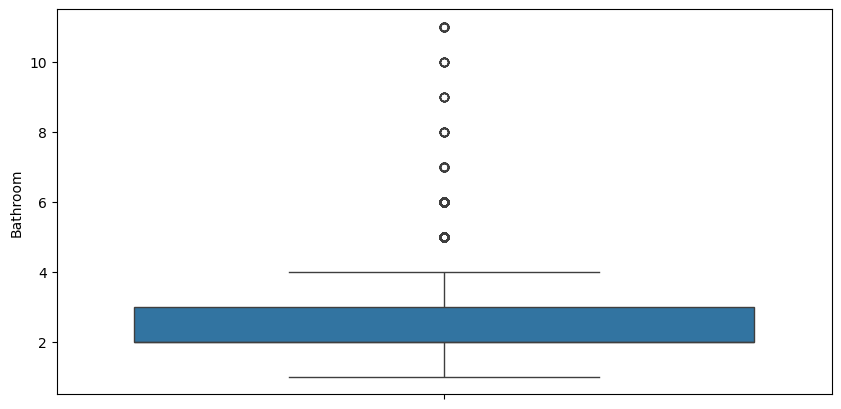

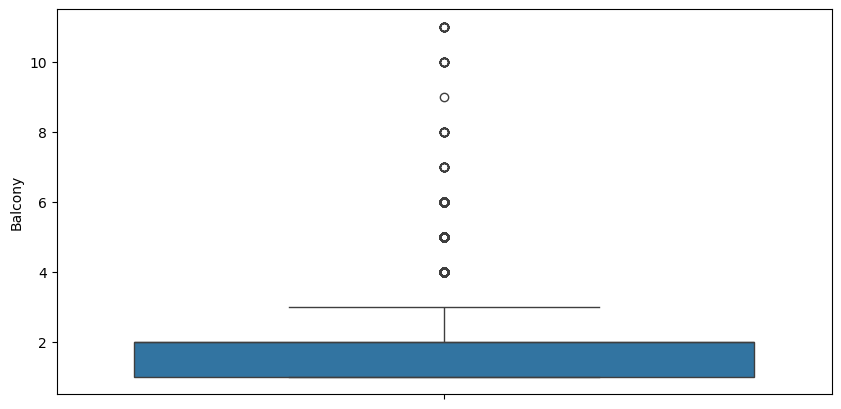

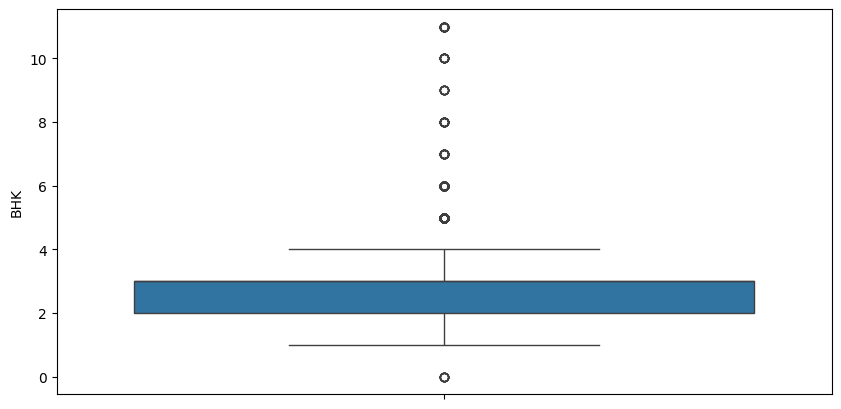

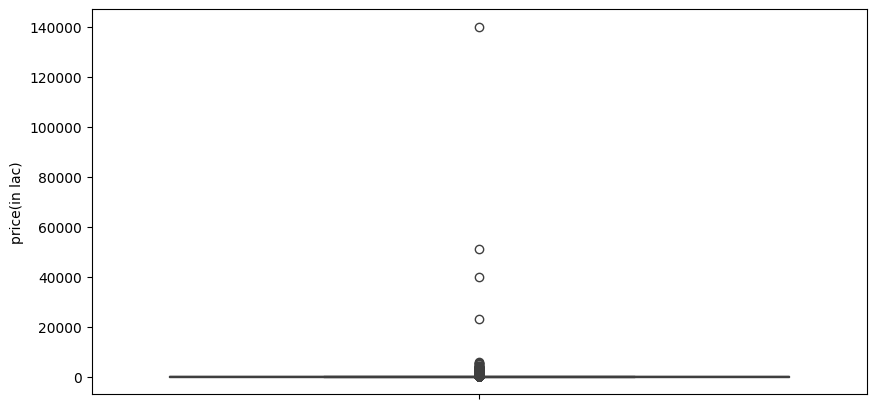

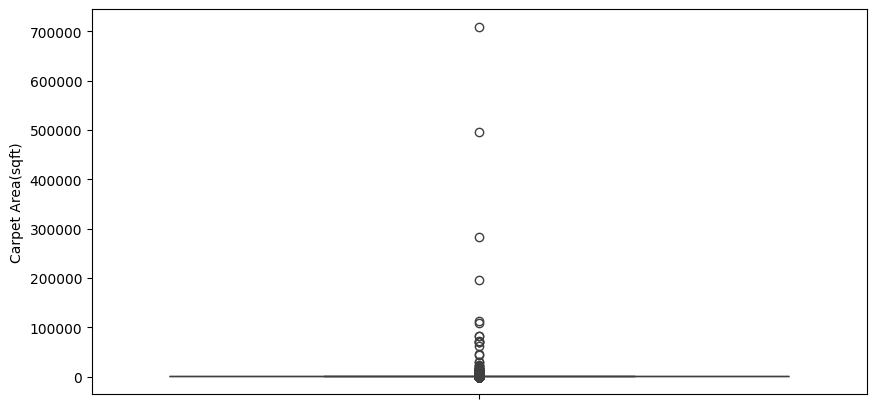

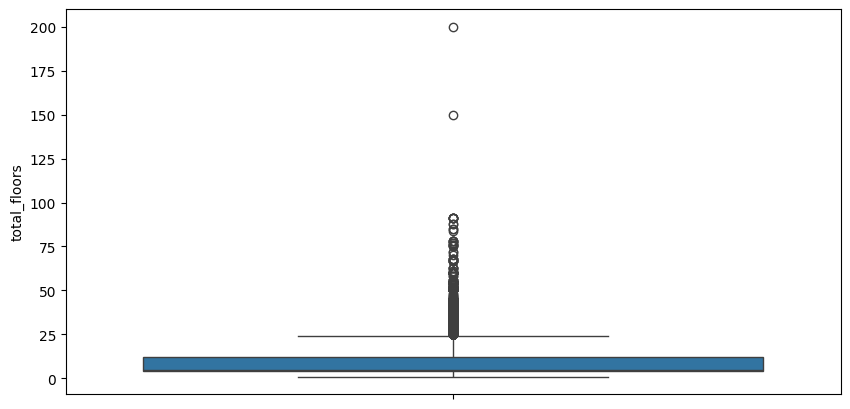

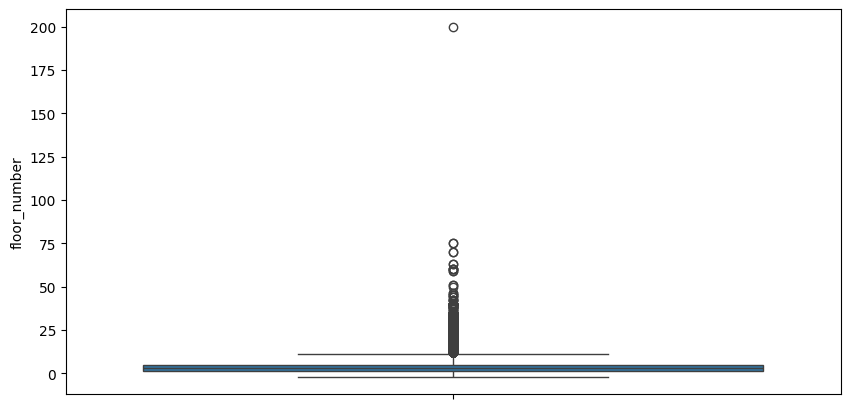

In [40]:
for i in df.columns:
  if df[i].dtypes != 'object':
    plt.figure(figsize=(10,5))
    sns.boxplot(df[i])
    plt.show()

In [41]:
def outlier_report(df):
    results = []

    for col in df.select_dtypes(include=['int64', 'float64']).columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
        outlier_count = outliers.shape[0]
        total_count = df.shape[0]
        outlier_percent = (outlier_count / total_count) * 100

        results.append({
            "Column": col,
            "Outlier_Count": outlier_count,
            "Outlier_Percentage": round(outlier_percent, 2)
        })

    return pd.DataFrame(results)

outlier_report(df)

,Column,Outlier_Count,Outlier_Percentage
0,Bathroom,3486,2.22
1,Balcony,6745,4.29
2,BHK,1264,0.80
3,price(in lac),13620,8.67
4,Carpet Area(sqft),62354,39.68
5,total_floors,8152,5.19
6,floor_number,13686,8.71


In [42]:
max(df['Carpet Area(sqft)']),min(df['Carpet Area(sqft)'])

(709222.0, 1.0)

In [43]:
max(df['price(in lac)']),min(df['price(in lac)'])

(140030.0, 1.0)

In [44]:
df = df[df['Carpet Area(sqft)'] < 10000]
df = df[df['Carpet Area(sqft)'] > 200]

df = df[df['price(in lac)'] < 1000]
df = df[df['price(in lac)'] > 5]

In [45]:
df.shape

(151376, 12)

In [46]:
def correlation(dataset, threshold):
    col_corr = set()
    corr_matrix = dataset.select_dtypes(include=np.number).corr()
    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            if abs(corr_matrix.iloc[i, j]) > threshold:
                colname = corr_matrix.columns[i]
                col_corr.add(colname)
    return col_corr

In [ ]:
## threshold--Domain expertise
corr_features=correlation(df,0.85)
corr_features

set()

## ML model deploy

In [48]:
x = df.drop(['price(in lac)'],axis=1)
y = df['price(in lac)']

In [49]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [50]:
x_train.shape,x_test.shape,y_train.shape,y_test.shape

((121100, 11), (30276, 11), (121100,), (30276,))

In [51]:
x_train.head()

,location,Transaction,Furnishing,facing,Bathroom,Balcony,Ownership,BHK,Carpet Area(sqft),total_floors,floor_number
52362,gurgaon,Resale,Semi-Furnished,East,2.0,1.0,Freehold,2,650.0,4.0,3.0
137183,new-delhi,Resale,Unfurnished,North - West,2.0,2.0,Freehold,2,1000.0,2.0,1.0
169958,mangalore,Resale,Furnished,East,3.0,3.0,Freehold,3,1000.0,7.0,4.0
49334,chennai,Resale,Semi-Furnished,North,2.0,1.0,Freehold,2,1000.0,3.0,2.0
53588,gurgaon,Resale,Semi-Furnished,East,3.0,3.0,Freehold,3,1300.0,20.0,11.0


In [52]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import RobustScaler,OrdinalEncoder

cat_col = x.select_dtypes(include='object').columns
num_col = x.select_dtypes(include='number').columns

tns = ColumnTransformer(transformers=[('cat',OrdinalEncoder(),cat_col),
                                      ('num',RobustScaler(),num_col)])

In [53]:
x_train_trans = tns.fit_transform(x_train)
x_train_trans = pd.DataFrame(x_train_trans,columns=x_train.columns)

In [54]:
x_test_trans = tns.transform(x_test)
x_test_trans = pd.DataFrame(x_test_trans,columns=x_test.columns)

In [55]:
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor()
rf.fit(x_train_trans,y_train)

RandomForestRegressor()

In [56]:
from sklearn.metrics import r2_score
y_pred = rf.predict(x_test_trans)
r2_score(y_test,y_pred)

0.9170515941938862

In [57]:
y_pred1 = rf.predict(x_train_trans)
r2_score(y_train,y_pred1)


0.9860474591595928

In [58]:
from sklearn.ensemble import GradientBoostingRegressor
gbr = GradientBoostingRegressor()
gbr.fit(x_train_trans,y_train)

GradientBoostingRegressor()

In [59]:
y_pred = gbr.predict(x_test_trans)
r2_score(y_test,y_pred)

0.8302429502294026

In [60]:
y_pred1 = gbr.predict(x_train_trans)
r2_score(y_train,y_pred1)

0.8333515289741629

In [61]:
# from sklearn.model_selection import GridSearchCV
# from xgboost import XGBRegressor

# param_grid = {'n_estimators':[200,400,600],
#     'learning_rate':[0.01,0.05,0.1],
#     'max_depth':[3,5,7,9]}
# model = XGBRegressor()
# grid = GridSearchCV(model,param_grid,cv=5,scoring='r2',n_jobs=-1)
# grid.fit(x_train_trans, y_train)
# print(grid.best_params_)

# # best one {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 600}

In [66]:
from xgboost import XGBRegressor
grid = XGBRegressor(learning_rate= 0.1, max_depth = 7, n_estimators = 600)
grid.fit(x_train_trans, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=7,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=600,
             n_jobs=None, num_parallel_tree=None, ...)

In [67]:
y_pred = grid.predict(x_test_trans)
r2_score(y_test,y_pred)

0.9249785144182588

In [68]:
y_pred1 = grid.predict(x_train_trans)
r2_score(y_train,y_pred1)

0.9661496156580963

In [69]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(grid, x_train_trans, y_train, cv=5)

scores.mean()

np.float64(0.9222778864544827)

In [70]:
import joblib

joblib.dump(grid, "xgb_model.pkl")

['xgb_model.pkl']

In [71]:
joblib.dump(tns, "preprocessor.pkl")

['preprocessor.pkl']

In [1]:
import pandas as pd
import numpy as np
data = pd.read_csv('cleaned_data.csv')

In [4]:
for i in data.columns:
  if data[i].dtypes == 'object':
      print(f'{i} : {data[i].unique()}')

location : ['thane' 'navi-mumbai' 'nagpur' 'mumbai' 'ahmedabad' 'bangalore' 'chennai'
 'gurgaon' 'hyderabad' 'indore' 'jaipur' 'kolkata' 'lucknow' 'new-delhi'
 'noida' 'pune' 'agra' 'ahmadnagar' 'allahabad' 'aurangabad' 'badlapur'
 'belgaum' 'bhiwadi' 'bhiwandi' 'bhopal' 'bhubaneswar' 'chandigarh'
 'coimbatore' 'dehradun' 'durgapur' 'ernakulam' 'faridabad' 'ghaziabad'
 'goa' 'greater-noida' 'guntur' 'guwahati' 'gwalior' 'haridwar' 'jabalpur'
 'jamshedpur' 'jodhpur' 'kalyan' 'kanpur' 'kochi' 'kozhikode' 'ludhiana'
 'madurai' 'mangalore' 'mohali' 'mysore' 'nashik' 'navsari' 'nellore'
 'palakkad' 'palghar' 'panchkula' 'patna' 'pondicherry' 'raipur'
 'rajahmundry' 'ranchi' 'satara' 'shimla' 'siliguri' 'solapur' 'sonipat'
 'surat' 'thrissur' 'tirupati' 'trichy' 'trivandrum' 'udaipur' 'udupi'
 'vadodara' 'vapi' 'varanasi' 'vijayawada' 'visakhapatnam' 'vrindavan'
 'zirakpur']
Status : ['Ready' 'Not Specified']
Transaction : ['Resale' 'New Property' 'Other']
Furnishing : ['Unfurnished' 'Semi-F